In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/karlyn/Downloads/METABRIC_RNA_Mutation.csv")
print(df.shape)
df.head()

(1904, 693)


/var/folders/d0/kk1nw8tn2t502y3p5gfp5yxc0000gn/T/ipykernel_16335/592801649.py:5: DtypeWarning: Columns (678,688,690,692) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/karlyn/Downloads/METABRIC_RNA_Mutation.csv")


,patient_id,age_at_diagnosis,type_of_breast_surgery,cancer_type,cancer_type_detailed,cellularity,chemotherapy,pam50_+_claudin-low_subtype,cohort,er_status_measured_by_ihc,...,mtap_mut,ppp2cb_mut,smarcd1_mut,nras_mut,ndfip1_mut,hras_mut,prps2_mut,smarcb1_mut,stmn2_mut,siah1_mut
0,0,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,0,claudin-low,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
1,2,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,0,LumA,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
2,5,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
3,6,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0
4,8,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,1,LumB,1.0,Positve,...,0,0,0,0,0,0,0,0,0,0


In [19]:
#target column
target_col = "pam50_+_claudin-low_subtype"
#removal of other columns
non_gene_cols = [
    "patient_id",
    "age_at_diagnosis",
    "tumor_size",
    "lymph_nodes_examined_positive",
    target_col
]

non_gene_cols = [col for col in non_gene_cols if col in df.columns]

gene_cols = [col for col in df.columns if col not in non_gene_cols]

print("Number of gene columns:", len(gene_cols))

#removings rows missing subtype
df = df.dropna(subset=[target_col])
#convert gene columns to numeric 
for col in gene_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# check which gene columns are all missing
all_missing_genes = [col for col in gene_cols if df[col].isnull().all()]

print("All-missing gene columns:", len(all_missing_genes))
print(all_missing_genes[:20])  # show first few

# remove them from gene_cols
gene_cols = [col for col in gene_cols if col not in all_missing_genes]

print("Remaining gene columns:", len(gene_cols))
#missing genes
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(df[gene_cols]), columns=gene_cols)

y = df[target_col].reset_index(drop=True)
#remove low variance genes
variances = X.var()

# keep only genes with decent variation
threshold = 0.01
high_var_genes = variances[variances > threshold].index

X = X[high_var_genes]

print("Remaining genes after filtering:", X.shape[1])
#combined clean dataset
clean_df = pd.concat([X, y], axis=1)


Number of gene columns: 688
All-missing gene columns: 15
['type_of_breast_surgery', 'cancer_type', 'cancer_type_detailed', 'cellularity', 'er_status_measured_by_ihc', 'er_status', 'her2_status_measured_by_snp6', 'her2_status', 'tumor_other_histologic_subtype', 'inferred_menopausal_state', 'primary_tumor_laterality', 'oncotree_code', 'pr_status', '3-gene_classifier_subtype', 'death_from_cancer']
Remaining gene columns: 673
Remaining genes after filtering: 500


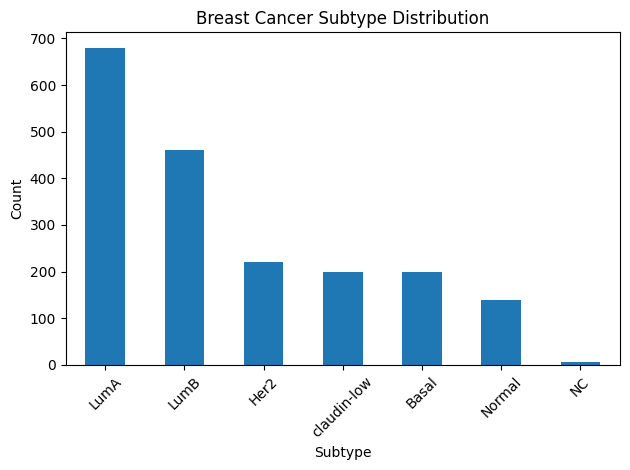

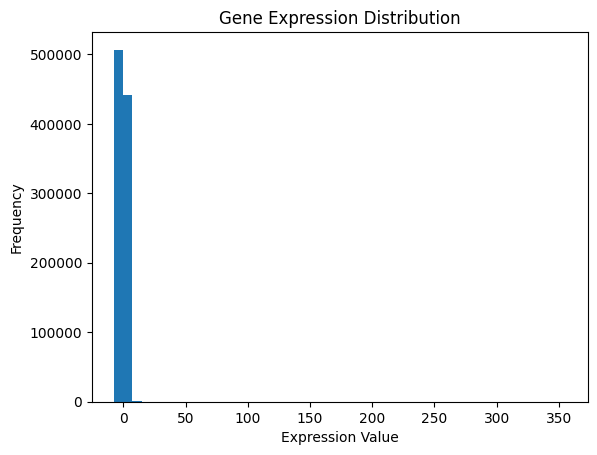

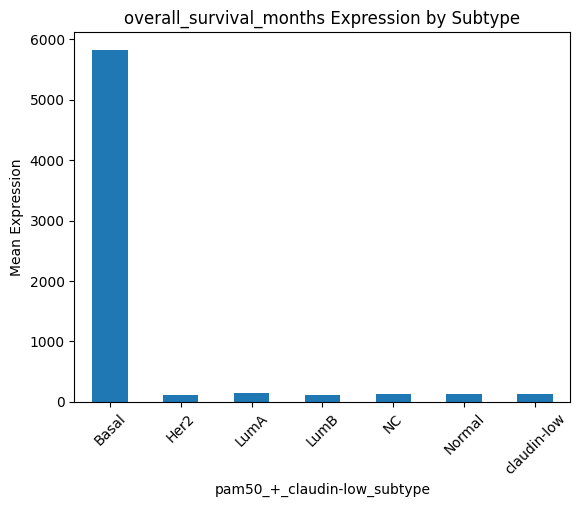

In [9]:
#data exploration
#class distribution
clean_df[target_col].value_counts().plot(kind="bar")
plt.title("Breast Cancer Subtype Distribution")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
#distribtution of gene expresions
all_values = X.values.flatten()
plt.hist(all_values, bins=50)
plt.title("Gene Expression Distribution")
plt.xlabel("Expression Value")
plt.ylabel("Frequency")
plt.show()
#genes across subtypes
top_genes = X.var().sort_values(ascending=False).head(10)
top_genes.plot(kind="bar")
gene = top_genes.index[0]
clean_df.groupby(target_col)[gene].mean().plot(kind="bar")
plt.title(f"{gene} Expression by Subtype")
plt.ylabel("Mean Expression")
plt.xticks(rotation=45)
plt.show()

In [35]:
#normalize the data:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)